STEP ในการ RUN \
Input (station)\
→ Batch inspection\
→ inspection_df\
→ CSV\
→ KPI Report\
→ Graph ✅

รัน Cell นี้ แล้วเลือกไฟล์
N8N_Production_Station_Datasheet.xlsx

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving N8N_Production_Station_Datasheet.xlsx to N8N_Production_Station_Datasheet.xlsx


พอรันแล้ว Colab จะ:

เปิดหน้าต่างให้เลือกไฟล์
อัปโหลด
N8N_Production_Station_Datasheet.xlsx

In [ ]:
import pandas as pd

df = pd.read_excel("N8N_Production_Station_Datasheet.xlsx")
df.head()

,Station ID,Station Name,Process Description,Main Machine,Potential Damage Point,Damage Description,Root Cause,Dataset Class,Captured By,Stored Data
0,S1,Bottle Molding,Plastic bottle forming,Blow/Injection Molding Machine,Mold cavity / Temperature,Bottle deform / uneven thickness,"Incorrect temperature, mold wear",P1,Fixed Camera,Image + Metadata
1,S2,Cooling & Transfer,Cooling and bottle transfer,Cooling Unit + Conveyor,Cooling time / Gripper,Bottle slight deform,Insufficient cooling time,P8,Fixed Camera,Image + Metadata
2,S3,Filling,Oil filling process,Liquid Filling Machine,Filling nozzle / level sensor,Overfill / Underfill / oil spill,Sensor miscalibration,P3,Fixed Camera,Image + Metadata
3,S4,Capping,Bottle cap sealing,Automatic Capper,Torque control head,Cap loose / broken,Incorrect torque setting,P4 / P5,Fixed Camera,Image + Metadata
4,S5,Inspection,Leak and level inspection,Vision / Leak Tester,Pressure testing unit,Bottle crack / false reject,Over-pressure or calibration error,P2,Vision System,Image + Metadata


ขั้นถัดไปคือ สร้าง Inspection Logic + Batch + CSV + Report + Graph

สร้าง Defect Rules จาก Excel

In [ ]:
DEFECT_RULES = {}
for _, row in df.iterrows():
    DEFECT_RULES[row["Station ID"]] = {
        "station_name": row["Station Name"],
        "process": row["Process Description"],
        "machine": row["Main Machine"],
        "class": row["Dataset Class"],
        "defect": row["Damage Description"],
        "root_cause": row["Root Cause"]
    }

print("Loaded stations:", list(DEFECT_RULES.keys()))


Loaded stations: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']


สร้างฟังก์ชัน inspect_bottle()

In [ ]:
import random
from datetime import datetime

def inspect_bottle(station_id: str):
    product = "Cooking Oil Bottle"

    if station_id not in DEFECT_RULES:
        return {"error": f"Station {station_id} not found"}

    rule = DEFECT_RULES[station_id]

    inspection_score = random.random()
    is_defect = inspection_score < 0.3

    result = {
        "timestamp": datetime.now().isoformat(),
        "station_id": station_id,
        "station_name": rule["station_name"],
        "product": product,
        "process": rule["process"],
        "machine": rule["machine"],
        "class": rule["class"],
        "inspection_score": round(inspection_score, 3),
        "result": "DEFECT" if is_defect else "OK"
    }

    if is_defect:
        result["defect"] = rule["defect"]
        result["root_cause"] = rule["root_cause"]

    return result


ทดสอบตรวจ 1 ขวด

วิธีใช้

กด Run cell

1.   กด Run cell
2.   Colab จะขึ้นช่องให้พิมพ์
2.   พิมพ์เช่น S1 - S8

In [ ]:
while True:
    station = input("Enter station ID (S1–S8): ").strip().upper()
    if station:
        break
    print("⚠️ Please enter a station ID")

inspect_bottle(station)

Enter station ID (S1–S8): 
⚠️ Please enter a station ID
Enter station ID (S1–S8): S2


{'timestamp': '2026-01-12T11:05:08.153071',
 'station_id': 'S2',
 'station_name': 'Cooling & Transfer',
 'product': 'Cooking Oil Bottle',
 'process': 'Cooling and bottle transfer',
 'machine': 'Cooling Unit + Conveyor',
 'class': 'P8',
 'inspection_score': 0.732,
 'result': 'OK'}

รับจำนวนขวด (Batch)

วิธีใช้

กด Run cell

1.   กด Run cell
2.   Colab จะขึ้นช่องให้พิมพ์
2.   พิมพ์เช่น 1-20 นั่นหมายถึง 1-20 ขวด

In [ ]:
n = int(input("Enter number of bottles to inspect (e.g. 20): "))

Enter number of bottles to inspect (e.g. 20): 18


In [ ]:
def run_batch(station_id, n=20):
    return [inspect_bottle(station_id) for _ in range(n)]
results = run_batch(station, n=n)
results[:5]

[{'timestamp': '2026-01-12T11:11:41.114721',
  'station_id': 'S2',
  'station_name': 'Cooling & Transfer',
  'product': 'Cooking Oil Bottle',
  'process': 'Cooling and bottle transfer',
  'machine': 'Cooling Unit + Conveyor',
  'class': 'P8',
  'inspection_score': 0.946,
  'result': 'OK'},
 {'timestamp': '2026-01-12T11:11:41.114759',
  'station_id': 'S2',
  'station_name': 'Cooling & Transfer',
  'product': 'Cooking Oil Bottle',
  'process': 'Cooling and bottle transfer',
  'machine': 'Cooling Unit + Conveyor',
  'class': 'P8',
  'inspection_score': 0.708,
  'result': 'OK'},
 {'timestamp': '2026-01-12T11:11:41.114767',
  'station_id': 'S2',
  'station_name': 'Cooling & Transfer',
  'product': 'Cooking Oil Bottle',
  'process': 'Cooling and bottle transfer',
  'machine': 'Cooling Unit + Conveyor',
  'class': 'P8',
  'inspection_score': 0.096,
  'result': 'DEFECT',
  'defect': 'Bottle slight deform',
  'root_cause': 'Insufficient cooling time'},
 {'timestamp': '2026-01-12T11:11:41.114778

In [ ]:
import pandas as pd

inspection_df = pd.DataFrame(results)
inspection_df

,timestamp,station_id,station_name,product,process,machine,class,inspection_score,result,defect,root_cause
0,2026-01-12T11:11:41.114721,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.946,OK,NaN,NaN
1,2026-01-12T11:11:41.114759,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.708,OK,NaN,NaN
2,2026-01-12T11:11:41.114767,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.096,DEFECT,Bottle slight deform,Insufficient cooling time
3,2026-01-12T11:11:41.114778,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.057,DEFECT,Bottle slight deform,Insufficient cooling time
4,2026-01-12T11:11:41.114784,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.880,OK,NaN,NaN
5,2026-01-12T11:11:41.114791,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.488,OK,NaN,NaN
6,2026-01-12T11:11:41.114797,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.395,OK,NaN,NaN
7,2026-01-12T11:11:41.114803,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.059,DEFECT,Bottle slight deform,Insufficient cooling time
8,2026-01-12T11:11:41.114810,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.459,OK,NaN,NaN
9,2026-01-12T11:11:41.114816,S2,Cooling & Transfer,Cooking Oil Bottle,Cooling and bottle transfer,Cooling Unit + Conveyor,P8,0.981,OK,NaN,NaN


บันทึกเป็น CSV (Execution Log)

In [ ]:
inspection_df.to_csv("inspection_results.csv", index=False)
print("✅ Saved inspection_results.csv")

✅ Saved inspection_results.csv


สร้าง Report (KPI)

*   Overall KPI (OK vs DEFECT)


In [ ]:
overall_kpi = (
    inspection_df
    .groupby("result")
    .agg(
        count=("result", "count"),
        avg_score=("inspection_score", "mean")
    )
    .reset_index()
)

overall_kpi


,result,count,avg_score
0,DEFECT,6,0.077500
1,OK,12,0.719667


Station KPI (Defect Rate)

In [ ]:
station_kpi = (
    inspection_df
    .groupby(["station_id", "result"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

station_kpi["total"] = station_kpi.drop(columns=["station_id"]).sum(axis=1)
station_kpi["defect_rate"] = (
    station_kpi.get("DEFECT", 0) / station_kpi["total"]
).round(3)

station_kpi


result,station_id,DEFECT,OK,total,defect_rate
0,S2,6,12,18,0.333


In [ ]:
total = len(inspection_df)
ok = (inspection_df["result"] == "OK").sum()
defects = (inspection_df["result"] == "DEFECT").sum()

summary = f"""
INSPECTION REPORT SUMMARY
=========================
Station: {station}
Total inspections: {total}
OK: {ok}
DEFECT: {defects}
Defect rate: {defects/total:.2%}
"""

print(summary)



INSPECTION REPORT SUMMARY
Station: S2
Total inspections: 18
OK: 12
DEFECT: 6
Defect rate: 33.33%



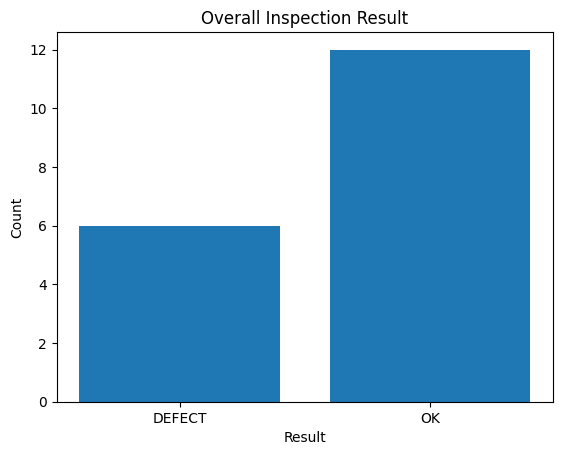

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(overall_kpi["result"], overall_kpi["count"])
plt.title("Overall Inspection Result")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()


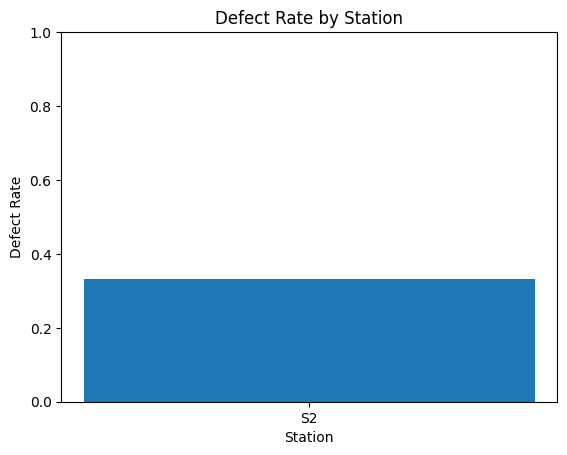

In [ ]:
plt.figure()
plt.bar(station_kpi["station_id"], station_kpi["defect_rate"])
plt.title("Defect Rate by Station")
plt.xlabel("Station")
plt.ylabel("Defect Rate")
plt.ylim(0, 1)
plt.show()
